In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Input
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.densenet import DenseNet201, preprocess_input
from efficientnet import tfkeras as efficientnet

In [2]:
sdir=r'C:\Users\LENOVO\Documents\penyakit1\dataset\train'

filepaths=[]
labels=[]
classlist=os.listdir(sdir)
for klass in classlist:
    classpath=os.path.join(sdir,klass)
    if os.path.isdir(classpath):
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            filepaths.append(fpath)
            labels.append(klass)
Fseries= pd.Series(filepaths, name='filepaths')
Lseries=pd.Series(labels, name='labels')
df=pd.concat([Fseries, Lseries], axis=1)
print (df.head())
print (df['labels'].value_counts())

                                           filepaths     labels
0  C:\Users\LENOVO\Documents\penyakit1\dataset\tr...  BrownSpot
1  C:\Users\LENOVO\Documents\penyakit1\dataset\tr...  BrownSpot
2  C:\Users\LENOVO\Documents\penyakit1\dataset\tr...  BrownSpot
3  C:\Users\LENOVO\Documents\penyakit1\dataset\tr...  BrownSpot
4  C:\Users\LENOVO\Documents\penyakit1\dataset\tr...  BrownSpot
HealthyLeaf    130
LeafBlight     123
LeafSmut       123
BrownSpot       88
LeafBlast       80
Name: labels, dtype: int64


In [3]:
# Split dataset
train_split, test_split = 0.8, 0.1
dummy_split = test_split / (1 - train_split)
train_df, dummy_df = train_test_split(df, train_size=train_split, shuffle=True, random_state=123)
test_df, valid_df = train_test_split(dummy_df, train_size=dummy_split, shuffle=True, random_state=123)
print('Train size:', len(train_df), ' Test size:', len(test_df), ' Validation size:', len(valid_df))

Train size: 435  Test size: 54  Validation size: 55


In [4]:
# Image dimensions and batch size
height, width, channels = 128, 128, 3
batch_size = 64
img_size = (height, width)

In [5]:
# Data generators
gen = ImageDataGenerator(rescale=1./255)
train_gen = gen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical', batch_size=batch_size, shuffle=True)
valid_gen = gen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical', batch_size=batch_size, shuffle=True)
test_gen = gen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical', batch_size=batch_size, shuffle=False)

Found 435 validated image filenames belonging to 5 classes.
Found 55 validated image filenames belonging to 5 classes.
Found 54 validated image filenames belonging to 5 classes.


In [6]:
# Classes
classes = list(train_gen.class_indices.keys())
class_count = len(classes)

In [7]:
# Base model
base_model = efficientnet.EfficientNetB0(input_shape=(128,128,3), 
                                 include_top=False,
                                 weights="imagenet")
base_model.trainable = False

In [8]:
# Build model
model = Sequential([
    base_model,
    Conv2D(64, (3, 3), activation='relu', padding='same', strides=1),
    MaxPooling2D(2, 2),
    Dropout(0.5),
    Flatten(),
    Dense(class_count, activation='softmax')
])

In [9]:
# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnet-b0 (Functional)         │ (None, 4, 4, 1280)          │       4,049,564 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 4, 4, 64)            │         737,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,788,193 (18.27 MB)

 Trainable params: 738,629 (2.82 MB)

 Non-trainable params: 4,049,564 (15.45 MB)

In [10]:
# Train model
history = model.fit(train_gen, epochs=10, validation_data=valid_gen)

# Save model
model.save('C:/Users/LENOVO/Documents/penyakit1/dataset/dataset.h5')
print("Model saved!")

Epoch 1/10


C:\Users\LENOVO\anaconda3\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.4874 - loss: 1.8402 - val_accuracy: 0.7455 - val_loss: 0.7856
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 942ms/step - accuracy: 0.7086 - loss: 0.8263 - val_accuracy: 0.7091 - val_loss: 0.7967
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 948ms/step - accuracy: 0.8165 - loss: 0.4920 - val_accuracy: 0.8000 - val_loss: 0.6090
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 951ms/step - accuracy: 0.8745 - loss: 0.3990 - val_accuracy: 0.8000 - val_loss: 0.5359
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 951ms/step - accuracy: 0.9003 - loss: 0.2835 - val_accuracy: 0.7818 - val_loss: 0.6067
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 984ms/step - accuracy: 0.9045 - loss: 0.2853 - val_accuracy: 0.8182 - val_loss: 0.6262
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 948ms/step - accuracy: 0.8936 - loss: 0.2957 - val_accuracy: 0.8000 - val_loss: 0.5634
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 945ms/step - accuracy: 0.8976 - loss: 0.2550 - val_accuracy: 0.8182 - val_loss: 0.637

Model saved!


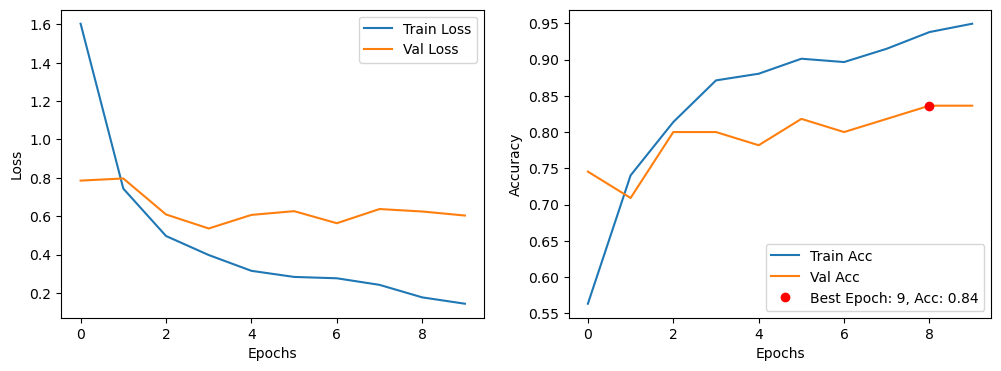

In [11]:
# Plot training history with best epoch annotation
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Find the best epoch for validation accuracy
    best_epoch = np.argmax(history.history['val_accuracy'])
    best_val_accuracy = history.history['val_accuracy'][best_epoch]
    
    # Annotate the best epoch on the validation accuracy plot
    plt.plot(best_epoch, best_val_accuracy, 'ro', label=f'Best Epoch: {best_epoch + 1}, Acc: {best_val_accuracy:.2f}')
    plt.legend()
    
    plt.show()

plot_history(history)


In [12]:
# Evaluate model
test_loss, test_acc = model.evaluate(test_gen, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")

1/1 - 2s - 2s/step - accuracy: 0.8519 - loss: 0.4119
Test accuracy: 0.85


In [13]:
# Predictions for calculating additional metrics
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=-1)

# Menampilkan nilai y_true dan y_pred secara terpisah
print("Nilai y_true:")
print(y_true)

print("\nNilai y_pred:")
print(y_pred)

print("\nNilai y_pred_probs:")
print(y_pred_probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Nilai y_true:
[4, 3, 2, 4, 4, 0, 3, 2, 3, 1, 3, 0, 4, 1, 1, 2, 4, 1, 2, 0, 3, 1, 4, 3, 4, 0, 1, 4, 1, 0, 4, 4, 0, 1, 3, 2, 1, 3, 4, 4, 1, 4, 1, 4, 3, 2, 4, 0, 1, 1, 2, 0, 2, 4]

Nilai y_pred:
[4 3 1 4 4 0 3 2 3 1 3 3 4 1 1 2 4 1 2 0 3 1 4 3 4 0 1 4 1 0 4 4 1 1 3 2 1
 3 4 4 2 4 2 4 3 2 4 1 1 1 1 0 1 4]

Nilai y_pred_probs:
[[1.20536117e-02 1.30797429e-02 2.91971993e-02 2.23745368e-02
  9.23295021e-01]
 [2.65837826e-07 4.02936742e-08 1.64536587e-07 9.99999523e-01
  2.95289859e-09]
 [6.28449721e-03 7.73441851e-01 1.26225501e-01 8.86056386e-03
  8.51875320e-02]
 [1.19524710e-01 9.12854273e-04 5.36054187e-03 5.94441080e-03
  8.68257582e-01]
 [3.82954369e-07 5.85058521e-12 6.73058986e-09 1.54199251e-10
  9.99999642e-01]
 [9.99995470e-01 2.29090080e-10 3.01413401e-08 3.76355933e-06
  6.76633874e-07]
 [3.79198939e-02 1.10462315e-04 1.26162823e-03 9.56706822e-01
  4.00115876e-03]
 [1.43819943e-03 1.50606677e-01 8.47809434e-01 1.12053611e-04
  3.36353914e-05]


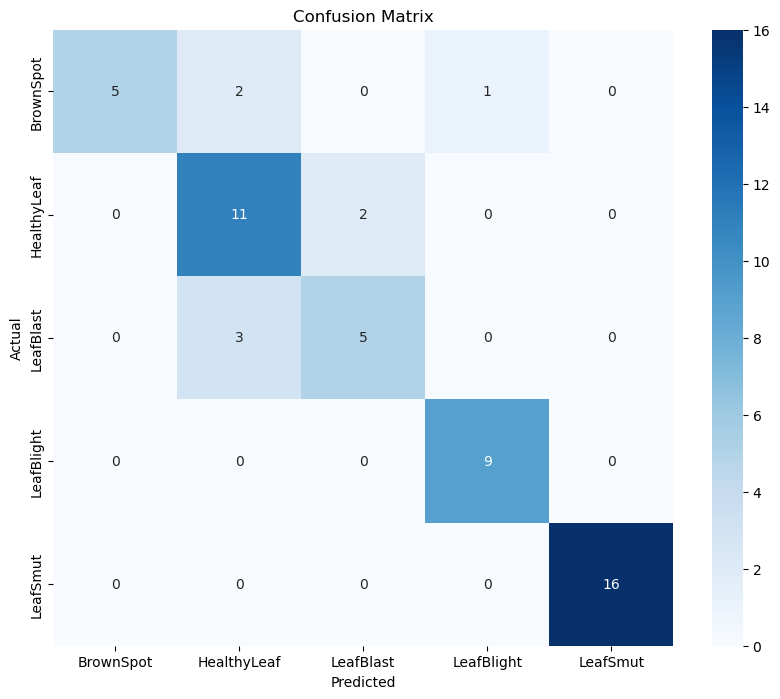

              precision    recall  f1-score   support

   BrownSpot       1.00      0.62      0.77         8
 HealthyLeaf       0.69      0.85      0.76        13
   LeafBlast       0.71      0.62      0.67         8
  LeafBlight       0.90      1.00      0.95         9
    LeafSmut       1.00      1.00      1.00        16

    accuracy                           0.85        54
   macro avg       0.86      0.82      0.83        54
weighted avg       0.87      0.85      0.85        54



In [14]:
# Confusion matrix and classification report
cm = confusion_matrix(y_true, y_pred)
clr = classification_report(y_true, y_pred, target_names=classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print(clr)

In [15]:
# MSE and MAE calculations
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error
y_true_one_hot = tf.keras.utils.to_categorical(y_true, num_classes=class_count)
mse = mean_squared_error(y_true_one_hot, y_pred_probs)
mae = mean_absolute_error(y_true_one_hot, y_pred_probs)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Mean Squared Error (MSE): 0.0465
Mean Absolute Error (MAE): 0.0731


In [16]:
# Prediction function
def predict_image_class(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128, 128))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array)
    predicted_class = classes[np.argmax(prediction)]
    
    plt.imshow(img)
    plt.title(f"Predicted Class: {predicted_class}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


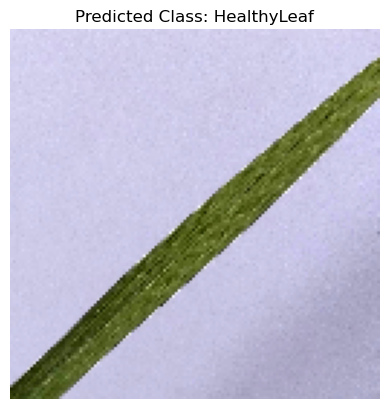

In [17]:
# Test the prediction function
img_path = 'C:/Users/LENOVO/Documents/penyakit1/dataset/train/HealthyLeaf/IMG_20190419_115237.jpg'
predict_image_class(img_path)